# PROJECT 1: PREDICTION AND MINIMIZATION OF PERSONAL LOAN DEFAULTS FOR ALPHA DREAMERS BANKING CONSORTIUM

## Overview
Alpha dreamers Banking consortium is a financial institution that provides business loans, savings accounts, and checking accounts for individuals and businesses.The loans department has realized that there is a high defaulter rate for personal loans and a machine learning pipeline is needed to predict and identify customers who potentially have a high risk of defaulting. These measures will allow the institution to optimize credit approval workflows and minimize capital loss.



##1.Load Banking Dataset

In [520]:
#importing the necessary libraries needed in this project
import pandas as pd     # For reading csv files and form data tables (DataFrames)
import numpy as np      # For high-level math and arrays (mathematical calculations)
import matplotlib.pyplot as plt  # For basic plotting
import seaborn as sns   # For beautiful statistical charts
from matplotlib.ticker import FormatStrFormatter
#To import my graphs
from google.colab import files


# For panda to read Banking csv file and turn into a dataframe
orig_df = pd.read_csv('/content/drive/MyDrive/CSEdata.csv')
orig_df.head() #shows the 5 rows of the Dataset

,Id,Income,Age,Experience,Married/Single,House_Ownership,Car_Ownership,Profession,CITY,STATE,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
0,1,1303834,23,3,single,rented,no,Mechanical_engineer,Rewa,Madhya_Pradesh,3,13,0
1,2,7574516,40,10,single,rented,no,Software_Developer,Parbhani,Maharashtra,9,13,0
2,3,3991815,66,4,married,rented,no,Technical_writer,Alappuzha,Kerala,4,10,0
3,4,6256451,41,2,single,rented,yes,Software_Developer,Bhubaneswar,Odisha,2,12,1
4,5,5768871,47,11,single,rented,no,Civil_servant,Tiruchirappalli[10],Tamil_Nadu,3,14,1


##2. Data Inspection and Cleaning

In [521]:
#Get a summary of columns, data types, and missing counts
#it tells you if a column is a "float" (number), "int" (whole number), or "object" (text).
#if the column that should have a datatype of "int" but it is "object" then we will know we have a formatting error
orig_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252000 entries, 0 to 251999
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Id                 252000 non-null  int64 
 1   Income             252000 non-null  int64 
 2   Age                252000 non-null  int64 
 3   Experience         252000 non-null  int64 
 4   Married/Single     252000 non-null  object
 5   House_Ownership    252000 non-null  object
 6   Car_Ownership      252000 non-null  object
 7   Profession         252000 non-null  object
 8   CITY               252000 non-null  object
 9   STATE              252000 non-null  object
 10  CURRENT_JOB_YRS    252000 non-null  int64 
 11  CURRENT_HOUSE_YRS  252000 non-null  int64 
 12  Risk_Flag          252000 non-null  int64 
dtypes: int64(7), object(6)
memory usage: 25.0+ MB


* The columns each have their respective data type and there is no missing count.

In [522]:
orig_df.shape

(252000, 13)

* Total number of row entries is 252000 and there 13 data columns for the entire dataset.

In [523]:
# To see the list of all column names in your DataFrame
print(orig_df.columns.tolist())

['Id', 'Income', 'Age', 'Experience', 'Married/Single', 'House_Ownership', 'Car_Ownership', 'Profession', 'CITY', 'STATE', 'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS', 'Risk_Flag']


In [524]:
#Get statistical summaries (Mean, Median, Max, etc.), which tells you if you have "outliers."
#For example, if the max age in your data is 180, you know there is a typing error.
orig_df.describe()

,Id,Income,Age,Experience,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
count,252000.000000,2.520000e+05,252000.000000,252000.000000,252000.000000,252000.000000,252000.000000
mean,126000.500000,4.997117e+06,49.954071,10.084437,6.333877,11.997794,0.123000
std,72746.278255,2.878311e+06,17.063855,6.002590,3.647053,1.399037,0.328438
min,1.000000,1.031000e+04,21.000000,0.000000,0.000000,10.000000,0.000000
25%,63000.750000,2.503015e+06,35.000000,5.000000,3.000000,11.000000,0.000000
50%,126000.500000,5.000694e+06,50.000000,10.000000,6.000000,12.000000,0.000000
75%,189000.250000,7.477502e+06,65.000000,15.000000,9.000000,13.000000,0.000000
max,252000.000000,9.999938e+06,79.000000,20.000000,14.000000,14.000000,1.000000


In [525]:
# We are checking if there are empty cells are in each column and how many they are
missing_data = orig_df.isnull().sum()
print(missing_data)

Id                   0
Income               0
Age                  0
Experience           0
Married/Single       0
House_Ownership      0
Car_Ownership        0
Profession           0
CITY                 0
STATE                0
CURRENT_JOB_YRS      0
CURRENT_HOUSE_YRS    0
Risk_Flag            0
dtype: int64


* There are no empty cells in each column.

In [526]:
#Remove the ID column (it doesn't help predict risk)
orig_df.drop('Id', axis=1, inplace=True)

In [527]:
#Clean the 'CITY' column with the Regular Expression: r'\[.*\]'
# Some city names like 'Tiruchirappalli[10]' have numbers in brackets.
# We remove anything in brackets using a regular expression.

'''We are removing the brackets from the cities because a
computer will see 'Tiruchirappalli[10]' and 'Tiruchirappalli
as two completely different entities when its still one CITY,
so we group them together so that the model learns the average rsk
for 'Tiruchirappalli based on all available rows. '''

#N.B. The brackets are not known what they might be or represent so they are not needed.
# We take them to be inconsistent patterns in text data like extra numbers, symbols etc.

orig_df['CITY'] = orig_df['CITY'].str.replace(r'\[.*\]', '', regex=True)


* \[ : Finds the opening bracket [ (the backslash is used because brackets have special meanings in code).

* .* : The dot . means "any character" and the star * means "any number of times." This finds everything inside the brackets.

* \] : Finds the closing bracket ].

* The '' (the second part of the function) represents an empty string.

In [528]:
# To check and count the total number of duplicate rows in the entire dataset
print(orig_df.duplicated().sum())

208810


* There are 208810 total number of duplicates in the entire dataset.

In [529]:
#Remove duplicates
orig_df.drop_duplicates(inplace=True)

In [530]:
print(orig_df.shape)

(43190, 12)


* Now that the duplicates and the column Id have been removed, the dataframe of the entire dataset is 43190 rows and 12 columns.

### Data Visualization of the entire dataset

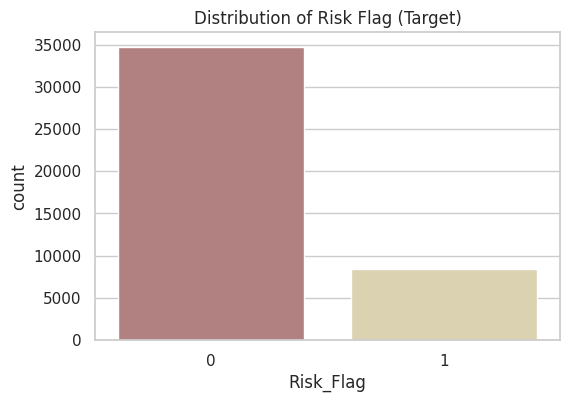

In [531]:
#Distribution of Risk Flag(Target Variable)
# Set the visual style
sns.set(style="whitegrid")

plt.figure(figsize=(6, 4))
sns.countplot(x='Risk_Flag', data=orig_df, hue='Risk_Flag', palette='pink', legend=False)
plt.title('Distribution of Risk Flag (Target)')
plt.savefig('target_distribution.png')

#Accessing my graph
#plt.savefig('my_graph.png')
#files.download('my_graph.png')

* Risk_Flag 0 represents low risk and Risk_Flag 1 represents high risk.
* Risk_Flag 0 appears to have a higher count of customers than Risk_Flag 1, which has a lower count of customers.

In conclusion, there are more low risk customers than high risk customers in the entire dataset.

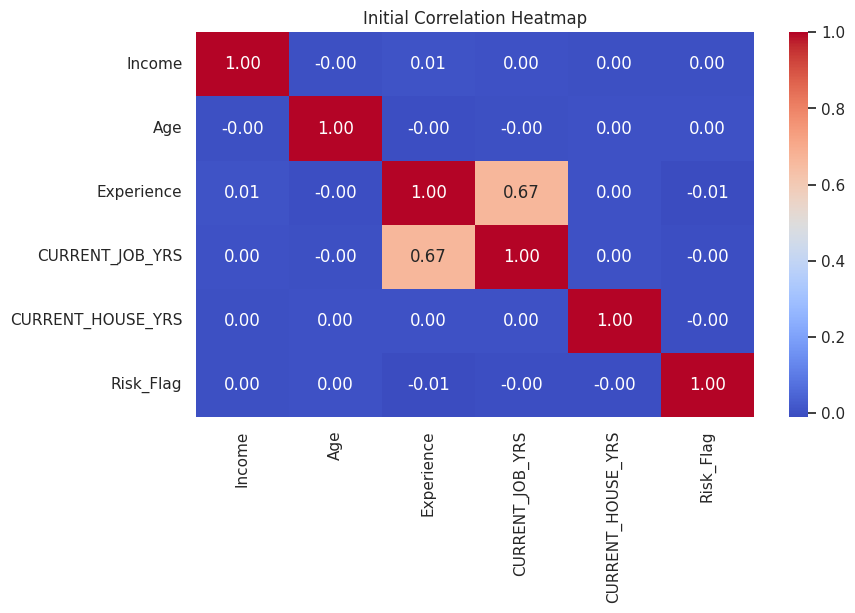

In [532]:
#Correlation Heatmap to check for correlation with target variable
plt.figure(figsize=(9, 5))

# We only correlate numeric columns
cols_to_use =['Income', 'Age', 'Experience',
                'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS', 'Risk_Flag']
sns.heatmap(orig_df[cols_to_use].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Initial Correlation Heatmap')
plt.savefig('correlation_heatmap.png')

#Accessing my graph
##plt.savefig('my_graph2.png')
##files.download('my_graph2.png')

* All the numerical datasets in the entire data have a 0.0 relation to target variable (Risk_Flag).
* The shows that no single numerical data like Income or Age etc. can perfectly predict if someone is a risk. They are independent of each other.
* However, Experience and CURRENT_JOB_YRS are linked. The 0.67 correlation confirms a strong link between total career length and current job tenure. While they move together, the gap between 0.67 and 1.0 highlights the 'job hoppers' in our dataset—people with high experience but low current job years. This is a crucial distinction for predicting loan risk, as total experience signals skill, while current job years signals immediate stability

**The code below wants to make the correlation between Experience and CURRENT_JOB_YRS 0 so that the features become independent features**
* Experience encompasses the number of previous work experience + current job years, that is why we see a 0.67% correlation. The need to separate them into independent features is to avoid multicollinearity.


In [533]:
# 1. Create Previous Experience feature
# We use the original column names from your main dataframe
orig_df['Previous_Experience'] = orig_df['Experience'] - orig_df['CURRENT_JOB_YRS']


# 3. Drop the original 'Experience' column
# We do this because the information is now safely stored in 'Previous_Exp'
orig_df = orig_df.drop('Experience', axis=1)

# 4. Check the first few rows to make sure the math looks right
print(orig_df[['CURRENT_JOB_YRS', 'Previous_Experience']].head())

   CURRENT_JOB_YRS  Previous_Experience
0                3                    0
1                9                    1
2                4                    0
3                2                    0
4                3                    8


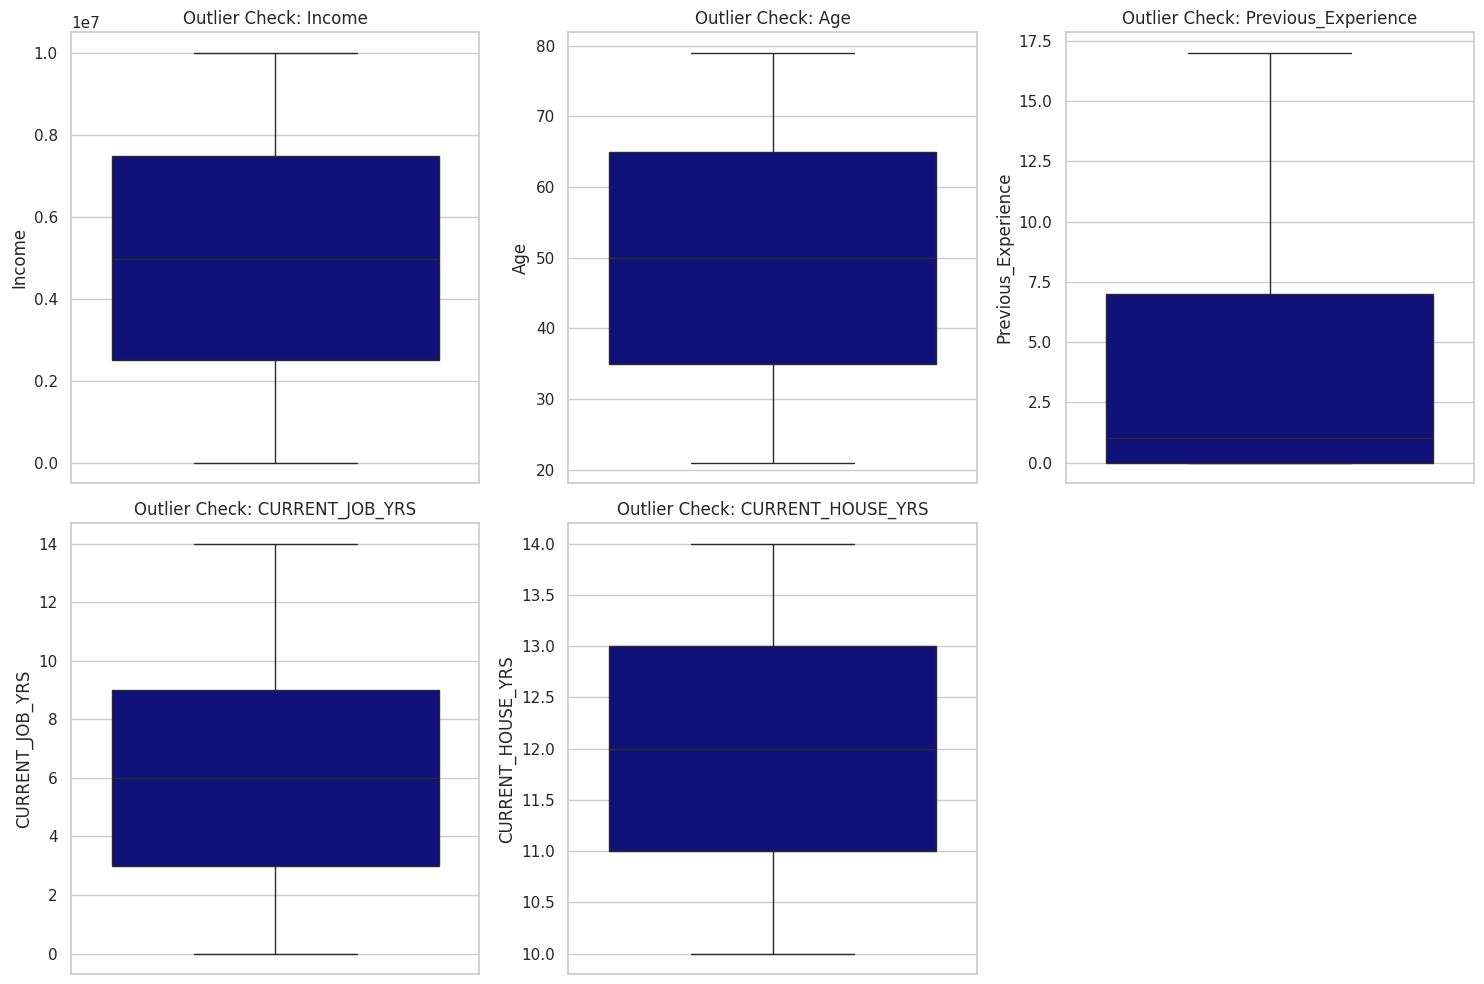

In [534]:
#Spotting Outliers with Boxplot
# List of all numerical columns
num_cols = ['Income', 'Age', 'Previous_Experience', 'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS']

# Create a "Subplot" (a grid of charts)
plt.figure(figsize=(15, 10))

for i, col in enumerate(num_cols):
    plt.subplot(2, 3, i+1) # Create a 2x3 grid
    sns.boxplot(y=orig_df[col], color='darkblue')
    plt.title(f'Outlier Check: {col}')

plt.tight_layout()
plt.show()

#Accessing my graph
##plt.savefig('my_graph3.png')
##files.download('my_graph3.png')

* There are no dots above or below the whiskers so the numerical data in the dataset is clean and stays within expected statistical range.

In [535]:
#Now lets get the final original dataframe description

orig_df.describe()

,Income,Age,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag,Previous_Experience
count,4.319000e+04,43190.000000,43190.000000,43190.000000,43190.000000,43190.000000
mean,4.999184e+06,49.917411,6.298981,12.006275,0.195485,3.676059
std,2.883155e+06,17.056702,3.663603,1.412652,0.396578,4.514988
min,1.031000e+04,21.000000,0.000000,10.000000,0.000000,0.000000
25%,2.508307e+06,35.000000,3.000000,11.000000,0.000000,0.000000
50%,4.984654e+06,50.000000,6.000000,12.000000,0.000000,1.000000
75%,7.494142e+06,65.000000,9.000000,13.000000,0.000000,7.000000
max,9.999938e+06,79.000000,14.000000,14.000000,1.000000,17.000000


##3. Splitting
We split before we do Data Preprocessing(encoding and scaling) to avoid data leakage.

* Data Leakage is when information from the test set (which is supposed to be unseen) accidentally leaks into your training set during preprocessing stage.
* This happens because when you encode or scale the entire dataset at once, the statistics of the test set(the average income or the frequency of 'Engineers') influence the values in the training set.
* This gives the model a sneak peak at the answers, leading to artificially high accuracy that fails in the real world.

In [536]:
from sklearn.model_selection import train_test_split

X = orig_df.drop('Risk_Flag', axis=1)
y = orig_df['Risk_Flag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

##4. Data Preprocessing
###Encoding

Encoding is the process of converting data that is usually in text format into a format  that a computer can understand, which is numerical. There are different types of encoding used in data science but in this particular project we will be using Binary Mapping, One-Hot Encoding and Target Encoding.

*   Binary Mapping: It is used when the variable/feature only has two options. For instance "yes/no", "male/female" etc.

*   One-Hot Encoding: It is used when there is no order between catergories. It creates and uses new dummy columns for the each categories of the specific column with more than two values. If the category is present in that specific dummy column then it gets 1 otherwise it gets 0.Best for low cardinality(2-5 categories).

* Target Encoding:It replaces a category with the average value of the target variable for that specific category. Best for high cardinality categories. For example, features such as City and Profession have more than 20 categories in this dataset.




In [537]:
#Check for the unique categories in text columns to see the rough number of categories
print("\n--- Unique Categories in Married/single ---")
print(orig_df['Married/Single'].unique())
print("\n--- Unique Categories in House_Ownership ---")
print(orig_df['House_Ownership'].unique())
print("\n--- Unique Categories in Car_Ownership ---")
print(orig_df['Car_Ownership'].unique())
print("\n--- Unique Categories in Profession ---")
print(orig_df['Profession'].unique())
print("\n--- Unique Categories in CITY ---")
print(orig_df['CITY'].unique())
print("\n--- Unique Categories in STATE ---")
print(orig_df['STATE'].unique())


--- Unique Categories in Married/single ---
['single' 'married']

--- Unique Categories in House_Ownership ---
['rented' 'norent_noown' 'owned']

--- Unique Categories in Car_Ownership ---
['no' 'yes']

--- Unique Categories in Profession ---
['Mechanical_engineer' 'Software_Developer' 'Technical_writer'
 'Civil_servant' 'Librarian' 'Economist' 'Flight_attendant' 'Architect'
 'Designer' 'Physician' 'Financial_Analyst' 'Air_traffic_controller'
 'Politician' 'Police_officer' 'Artist' 'Surveyor' 'Design_Engineer'
 'Chemical_engineer' 'Hotel_Manager' 'Dentist' 'Comedian'
 'Biomedical_Engineer' 'Graphic_Designer' 'Computer_hardware_engineer'
 'Petroleum_Engineer' 'Secretary' 'Computer_operator'
 'Chartered_Accountant' 'Technician' 'Microbiologist' 'Fashion_Designer'
 'Aviator' 'Psychologist' 'Magistrate' 'Lawyer' 'Firefighter' 'Engineer'
 'Official' 'Analyst' 'Geologist' 'Drafter' 'Statistician' 'Web_designer'
 'Consultant' 'Chef' 'Army_officer' 'Surgeon' 'Scientist' 'Civil_engineer'
 'Ind

In [538]:
#To completely remove the 'Future Warning'
pd.set_option('future.no_silent_downcasting', True)
# 1. Use binary mapping
mapping = {
    'Married/Single': {'single': 0, 'married': 1},
    'Car_Ownership': {'no': 0, 'yes': 1}
}

# 2. Add .infer_objects(copy=False) to tell Pandas to update the data types
X_train = X_train.replace(mapping).infer_objects(copy=False)
X_test = X_test.replace(mapping).infer_objects(copy=False)

print(X_train['Married/Single'].unique())

[0 1]


In [539]:
print(X_train[['Married/Single', 'Car_Ownership']].head())

        Married/Single  Car_Ownership
250934               0              1
230253               0              0
235054               0              1
230563               0              0
224460               0              0


In [540]:
#One-Hot Encoding for House_Ownership
#It has 3 categories (Rented, Owned, and Norent_noown)

from sklearn.preprocessing import OneHotEncoder


#Initialize the Encoder
# 'sparse_output=False' gives us a standard array we can easily put back into a DataFrame
# 'handle_unknown="ignore"' ensures your Web App won't crash if a user enters a weird value
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

#Fit and Transform the Training Column
#We reshape to (-1, 1) because the encoder expects a 2D input
ohe_train = ohe.fit_transform(X_train[['House_Ownership']])
ohe_test = ohe.transform(X_test[['House_Ownership']])

#Create DataFrame from the results
ohe_df_train = pd.DataFrame(ohe_train, columns=ohe.get_feature_names_out(['House_Ownership']), index=X_train.index)
ohe_df_test = pd.DataFrame(ohe_test, columns=ohe.get_feature_names_out(['House_Ownership']), index=X_test.index)

#Concatenate back to the original DataFrames and drop the old column
X_train = pd.concat([X_train.drop('House_Ownership', axis=1), ohe_df_train], axis=1)
X_test = pd.concat([X_test.drop('House_Ownership', axis=1), ohe_df_test], axis=1)

print(X_train.head())

         Income  Age  Married/Single  Car_Ownership    Profession  \
250934  4833956   32               0              1    Technician   
230253  5956759   26               0              0     Physician   
235054  7977647   42               0              1          Chef   
230563   135240   29               0              0          Chef   
224460  9648709   52               0              0  Army_officer   

                                CITY           STATE  CURRENT_JOB_YRS  \
250934  Raurkela_Industrial_Township          Odisha                9   
230253                       Jaunpur   Uttar_Pradesh                3   
235054                       Jaunpur   Uttar_Pradesh                7   
230563                      Warangal       Telangana                6   
224460                  Narasaraopet  Andhra_Pradesh                4   

        CURRENT_HOUSE_YRS  Previous_Experience  House_Ownership_norent_noown  \
250934                 12                    2                    

In [541]:
!pip install category_encoders

In [542]:
# TARGET ENCODING
from category_encoders import TargetEncoder

# 1. SAFETY STEP: Clean the categorical columns in X_train/X_test one last time
# This ensures that even if the split happened earlier, we are encoding CLEAN strings.
target_cols = ['Profession', 'CITY', 'STATE']

for col in target_cols:
    X_train[col] = X_train[col].astype(str).str.replace(r'[\[\]]', '', regex=True).str.strip()
    X_test[col] = X_test[col].astype(str).str.replace(r'[\[\]]', '', regex=True).str.strip()

# 2. Initialize the Encoder
t_encoder = TargetEncoder(cols=target_cols)

# 3. Fit and Transform
# Now the encoder only sees "Srinagar", never "[Srinagar]"
X_train = t_encoder.fit_transform(X_train, y_train)
X_test = t_encoder.transform(X_test)

print("Target Encoding complete. All brackets removed from encoder memory.")

Target Encoding complete. All brackets removed from encoder memory.


In [543]:
print(X_train.head())

         Income  Age  Married/Single  Car_Ownership  Profession      CITY  \
250934  4833956   32               0              1    0.220896  0.215384   
230253  5956759   26               0              0    0.183616  0.212388   
235054  7977647   42               0              1    0.206637  0.212388   
230563   135240   29               0              0    0.206637  0.180006   
224460  9648709   52               0              0    0.213396  0.279972   

           STATE  CURRENT_JOB_YRS  CURRENT_HOUSE_YRS  Previous_Experience  \
250934  0.213043                9                 12                    2   
230253  0.186401                3                 13                    3   
235054  0.186401                7                 13                    0   
230563  0.193047                6                 13                   13   
224460  0.207864                4                 14                    7   

        House_Ownership_norent_noown  House_Ownership_owned  \
250934     

In [544]:
print(X_train.shape)
print(X_test.shape)

(34552, 13)
(8638, 13)


* The train dataset has 34552 rows and 13 columns
* The test dataset has 8638 rows and 13 columns
* We have 13 columns now because of one-hot encoding it  created 3 new dummy columns from House_Ownership and dropped the House_Ownership that contained text.
* The new dummy columns are 'House_Ownership_rented', 'House_Ownership_owned' and 'House_Ownership_norent_noown'.

##5. Feature Engineering and Exploratory Data Analysis (EDA)

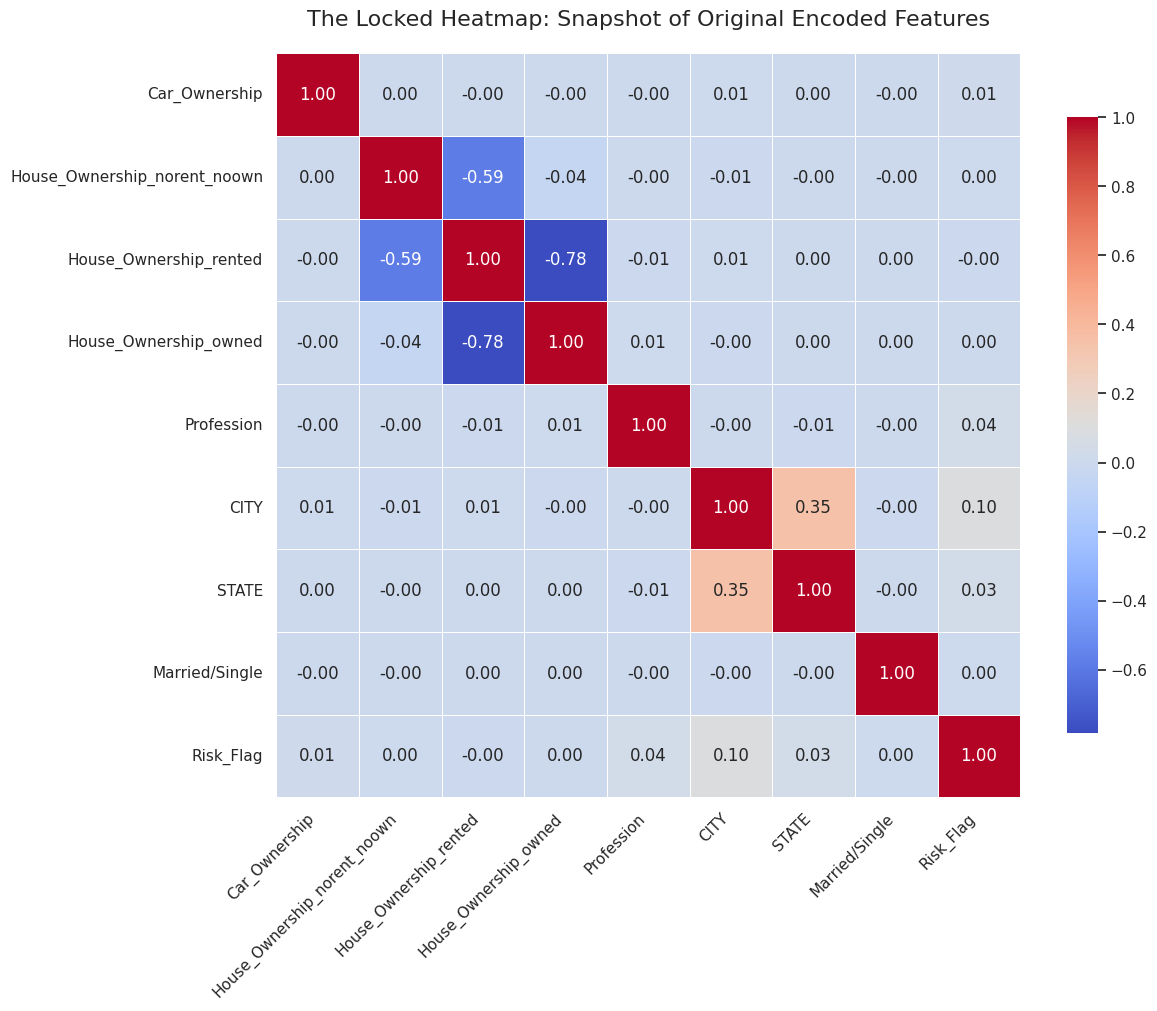

In [545]:
'''
A SNAPSHOT(.copy) WAS CREATED TO VISUALIZE THE CORRELATION OF FEATURES
 TO EACH OTHER ON THE X_train DATAFRAME BEFORE STARTING FEATURE ENGINEERING
 THAT COULD ALTER THIS HEATMAP
'''

#Create the 'Locked' Snapshot
#select only the encoded object columns and use .copy()
#This creates a brand new, independent object in memory
#use .copy() to avoid changing the original X_train
heatmap_data_snapshot= X_train[['Car_Ownership', 'House_Ownership_norent_noown', 'House_Ownership_rented',
                                'House_Ownership_owned', 'Profession', 'CITY', 'STATE', 'Married/Single']].copy()
heatmap_data_snapshot['Risk_Flag'] = y_train

#Calculate the Correlation Matrix on the snapshot only
corr_matrix = heatmap_data_snapshot.corr()

#Visualization
plt.figure(figsize=(12, 10))

#Create the heatmap
sns.heatmap(corr_matrix,
            annot=True,          # Shows the numbers inside the squares
            fmt=".2f",           # Limits decimals to 2
            cmap='coolwarm',     # Red for positive, Blue for negative
            linewidths=0.5,      # Adds lines between squares
            square=True,         # Makes the cells perfect squares
            cbar_kws={"shrink": .8})

# Customizing the look
plt.title('The Locked Heatmap: Snapshot of Original Encoded Features', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.show()

* Analysis shows a low-to-moderate correlation (0.35) between City and State risk scores. This indicates that geographic risk is not uniform across a state; rather, individual cities possess unique risk profiles that are independent of their regional location.

---

####**Asset Profile vs Default Rate**

**Question**: Does owning an asset like a house and car make a customer a low risk defaulter?

In [546]:
#Feature engineering of Home_Ownership dummy columns with Car_Ownership encoded columns, to create combined asset profiles.
def combined_asset_profiles(df):
    #Define the combinations based on your specific columns
    #We use string concatenation to create a readable label

    #We create a temporary label column
    conditions = [
        (df['House_Ownership_owned'] == 1) & (df['Car_Ownership'] == 1),
        (df['House_Ownership_owned'] == 1) & (df['Car_Ownership'] == 0),
        (df['House_Ownership_rented'] == 1) & (df['Car_Ownership'] == 1),
        (df['House_Ownership_rented'] == 1) & (df['Car_Ownership'] == 0),
        (df['House_Ownership_norent_noown'] == 1) & (df['Car_Ownership'] == 1),
        (df['House_Ownership_norent_noown'] == 1) & (df['Car_Ownership'] == 0)
    ]


    choices = [
        'Owner_With_Car', 'Owner_No_Car',
        'Renter_With_Car', 'Renter_No_Car',
        'NoRentNoHouse_With_Car', 'NoRentNoHouse_No_Car'
    ]

    #Apply labels
    df['asset_profile'] = np.select(conditions, choices, default='Other_Profile')

    #Turn these into dummy columns (1s and 0s), where 1 is True and 0 is False
    df = pd.get_dummies(df, columns=['asset_profile'], prefix='profile', dtype=int )

    return df

#Apply to both datasets
X_train = combined_asset_profiles(X_train)
X_test = combined_asset_profiles(X_test)


In [547]:
#Dropping the 'Raw' columns because our 'Asset feature' features are better
columns_to_drop = ['Car_Ownership',
    'House_Ownership_norent_noown',
    'House_Ownership_owned',
    'House_Ownership_rented'
]

#Drop them from the original DataFrames
X_train = X_train.drop(columns=columns_to_drop)
X_test = X_test.drop(columns=columns_to_drop)

#To check if the new columns for the combined asset profiles appear on the dataset
print("\n--- TRAINING DATAFRAME: LIST OF COLUMNS ---")
print(X_train.columns.tolist())
print("\n--- TESTING DATAFRAME: LIST OF COLUMNS ---")
print(X_test.columns.tolist())


--- TRAINING DATAFRAME: LIST OF COLUMNS ---
['Income', 'Age', 'Married/Single', 'Profession', 'CITY', 'STATE', 'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS', 'Previous_Experience', 'profile_NoRentNoHouse_No_Car', 'profile_NoRentNoHouse_With_Car', 'profile_Owner_No_Car', 'profile_Owner_With_Car', 'profile_Renter_No_Car', 'profile_Renter_With_Car']

--- TESTING DATAFRAME: LIST OF COLUMNS ---
['Income', 'Age', 'Married/Single', 'Profession', 'CITY', 'STATE', 'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS', 'Previous_Experience', 'profile_NoRentNoHouse_No_Car', 'profile_NoRentNoHouse_With_Car', 'profile_Owner_No_Car', 'profile_Owner_With_Car', 'profile_Renter_No_Car', 'profile_Renter_With_Car']


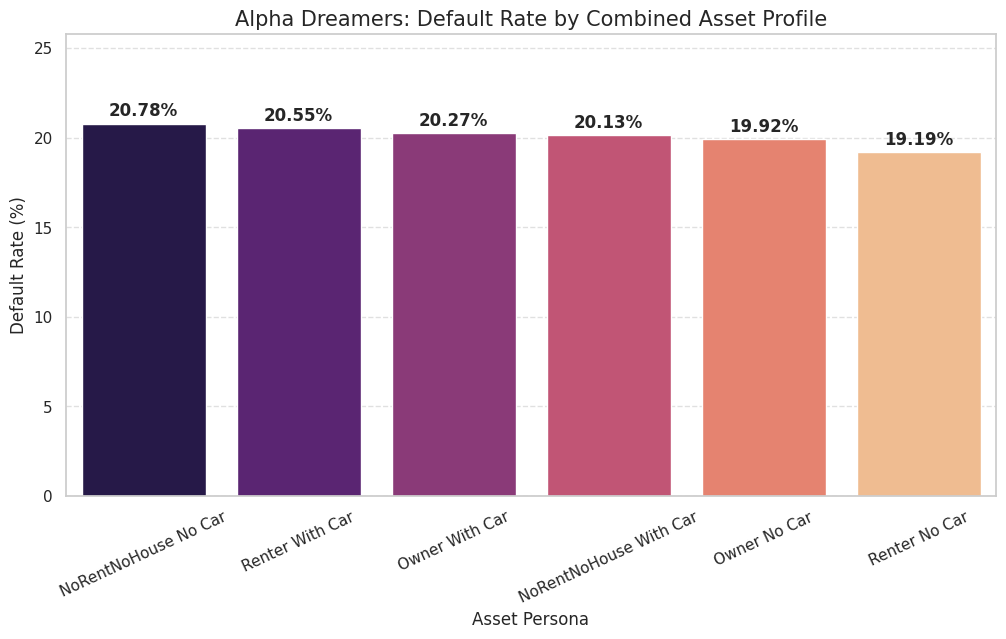

In [548]:
#VISUALIZATION FOR THE RESEARCH QUESTION FOR THE ASSSET PROFILE vs DEFAULT RATE
#Re-identify the profiles from your dummy columns for the plot labels
# We use the same choices you defined in your function
profile_cols = [
    'profile_Owner_With_Car', 'profile_Owner_No_Car',
    'profile_Renter_With_Car', 'profile_Renter_No_Car',
    'profile_NoRentNoHouse_With_Car', 'profile_NoRentNoHouse_No_Car'
]

#Calculate the Default Rate for each profile column
#We take the mean of y_train where the specific profile column is 1
rates = []
for col in profile_cols:
    # Get the average of Risk_Flag (y_train) only for rows where this profile == 1
    default_rate = y_train[X_train[col] == 1].mean() * 100
    rates.append({'Profile': col.replace('profile_', '').replace('_', ' '), 'Default_Rate': default_rate})

#Convert to a simple DataFrame for Seaborn
plot_df = pd.DataFrame(rates).sort_values('Default_Rate', ascending=False)

#Create the Bar Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=plot_df, x='Profile', y='Default_Rate', hue='Profile', palette='magma', legend=False)

#Add percentage labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9),
                textcoords='offset points', fontweight='bold')

plt.title('Alpha Dreamers: Default Rate by Combined Asset Profile', fontsize=15)
plt.ylabel('Default Rate (%)')
plt.xlabel('Asset Persona')
plt.xticks(rotation=25)
plt.ylim(0, plot_df['Default_Rate'].max() + 5) # Leave room for labels
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

**Interpretation for Asset Profile vs Default Rate**

Analysis identifies two distinct safe low risk profiles within the dataset. First, we observe that as a customer moves from having no assets to owning both a home and a vehicle, the default risk steadily declines from 20.78% to 20.27%. However, a second, more compelling trend emerges, where when customers who rent and do not own a vehicle exhibit the lowest overall default risk out of all the asset profiles. This suggests that for this specific demographic, minimal fixed overhead is a more powerful predictor of repayment than physical collateral.

---


#### **House Tenure vs Default Risk**
**Question**: Does  staying in house for a long time result to low default risks?

In [549]:
#HOUSE TENURE BINNING
def house_tenure_binning(h_tenure_df):
  #Create Micro-Bins for the 10-14 year range
  h_tenure_df['House_Tenure_Group'] = pd.cut(h_tenure_df['CURRENT_HOUSE_YRS'],
                                             bins = [9.9, 11.5, 13.5, 14.1],
                                             labels = ['10-11 Yrs', '12-13 Yrs', '14 Yrs (Max)'])

  #Convert these to dummy columns so the model can read them
  h_tenure_df = pd.get_dummies(h_tenure_df, columns=['House_Tenure_Group'], prefix='house_tenure', dtype=int)

  return h_tenure_df

#Apply to your actual training and testing data
X_train =  house_tenure_binning(X_train)
X_test =  house_tenure_binning(X_test)

#Remove the 'ghost' column that shouldn't be there
if 'Tenure_Micro_Group' in X_train.columns:
    X_train = X_train.drop(columns=['Tenure_Micro_Group'])

if 'Tenure_Micro_Group' in X_test.columns:
    X_test = X_test.drop(columns=['Tenure_Micro_Group'])

#This removes any column that has a name we've already seen
X_train = X_train.loc[:, ~X_train.columns.duplicated()]
X_test = X_test.loc[:, ~X_test.columns.duplicated()]

#Check the list again
print(X_train.columns.tolist())
print(X_test.columns.tolist())

['Income', 'Age', 'Married/Single', 'Profession', 'CITY', 'STATE', 'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS', 'Previous_Experience', 'profile_NoRentNoHouse_No_Car', 'profile_NoRentNoHouse_With_Car', 'profile_Owner_No_Car', 'profile_Owner_With_Car', 'profile_Renter_No_Car', 'profile_Renter_With_Car', 'house_tenure_10-11 Yrs', 'house_tenure_12-13 Yrs', 'house_tenure_14 Yrs (Max)']
['Income', 'Age', 'Married/Single', 'Profession', 'CITY', 'STATE', 'CURRENT_JOB_YRS', 'CURRENT_HOUSE_YRS', 'Previous_Experience', 'profile_NoRentNoHouse_No_Car', 'profile_NoRentNoHouse_With_Car', 'profile_Owner_No_Car', 'profile_Owner_With_Car', 'profile_Renter_No_Car', 'profile_Renter_With_Car', 'house_tenure_10-11 Yrs', 'house_tenure_12-13 Yrs', 'house_tenure_14 Yrs (Max)']


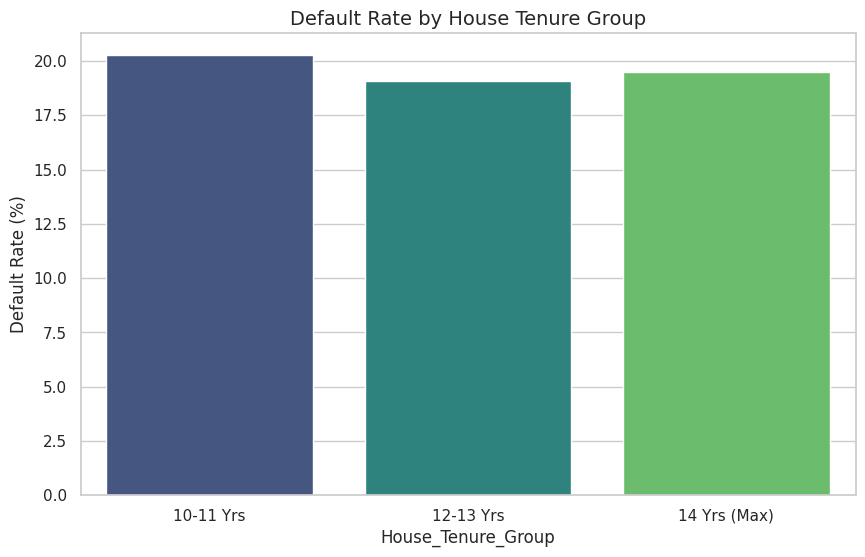

  House_Tenure_Group  Default_Rate
0          10-11 Yrs     20.271058
1          12-13 Yrs     19.088750
2       14 Yrs (Max)     19.509733


In [550]:
#VISUALIZATION OF RESEARCH QUESTION FOR HOUSE TENUREvs DEFAULT RATE

#Re-create the groups temporarily just for the calculation
temp_house_tenure_groups = pd.cut(X_train['CURRENT_HOUSE_YRS'],
                           bins = [9.9, 11.5, 13.5, 14.1],
                           labels = ['10-11 Yrs', '12-13 Yrs', '14 Yrs (Max)'])


#Combine with the target variable to calculate risk
#We use y_train (the Risk_Flag) and our temporary groups
h_tenure_risk_stats = y_train.groupby(temp_house_tenure_groups, observed=False).mean().reset_index()
h_tenure_risk_stats.columns = ['House_Tenure_Group', 'Default_Rate']

#Convert to percentage
h_tenure_risk_stats['Default_Rate'] = h_tenure_risk_stats['Default_Rate'] * 100

# Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(data=h_tenure_risk_stats, x='House_Tenure_Group', y='Default_Rate', hue='House_Tenure_Group', palette='viridis', legend=False)
plt.title('Default Rate by House Tenure Group', fontsize=14)
plt.ylabel('Default Rate (%)')
plt.show()

print(h_tenure_risk_stats)

**Interpretation for House Tenure vs Default Rate**
We discovered a low risk default for loan safety between 12 and 13 years of living in a home, where the risk of default is at its lowest (19.09%). Interestingly, those who have lived in their homes for slightly less time (10-11 years) are actually the riskiest group at 20.27%. Even more surprising is that after 13 years, the risk starts to creep back up again. This suggests that while staying in one place is generally good, the '14-Year Mark' brings new financial pressures—like home repairs or university fees as children leave the house. This shows a non-linear relationship so the longer one has resided in their house does not guarantee that they will be low defaulters.



In [551]:
#Dropping the 'Raw' columns because our 'Asset feature' features are better
columns_to_drop = ['CURRENT_HOUSE_YRS'
]

#Drop them from the original DataFrames
X_train = X_train.drop(columns=columns_to_drop)
X_test = X_test.drop(columns=columns_to_drop)

#To check if the new columns for the combined asset profiles appear on the dataset
print("\n--- TRAINING DATAFRAME: LIST OF COLUMNS ---")
print(X_train.columns.tolist())
print("\n--- TESTING DATAFRAME: LIST OF COLUMNS ---")
print(X_test.columns.tolist())


--- TRAINING DATAFRAME: LIST OF COLUMNS ---
['Income', 'Age', 'Married/Single', 'Profession', 'CITY', 'STATE', 'CURRENT_JOB_YRS', 'Previous_Experience', 'profile_NoRentNoHouse_No_Car', 'profile_NoRentNoHouse_With_Car', 'profile_Owner_No_Car', 'profile_Owner_With_Car', 'profile_Renter_No_Car', 'profile_Renter_With_Car', 'house_tenure_10-11 Yrs', 'house_tenure_12-13 Yrs', 'house_tenure_14 Yrs (Max)']

--- TESTING DATAFRAME: LIST OF COLUMNS ---
['Income', 'Age', 'Married/Single', 'Profession', 'CITY', 'STATE', 'CURRENT_JOB_YRS', 'Previous_Experience', 'profile_NoRentNoHouse_No_Car', 'profile_NoRentNoHouse_With_Car', 'profile_Owner_No_Car', 'profile_Owner_With_Car', 'profile_Renter_No_Car', 'profile_Renter_With_Car', 'house_tenure_10-11 Yrs', 'house_tenure_12-13 Yrs', 'house_tenure_14 Yrs (Max)']


---

#### **Marital Status vs Default rate**
**Question**: Does being married have a low risk default rate?

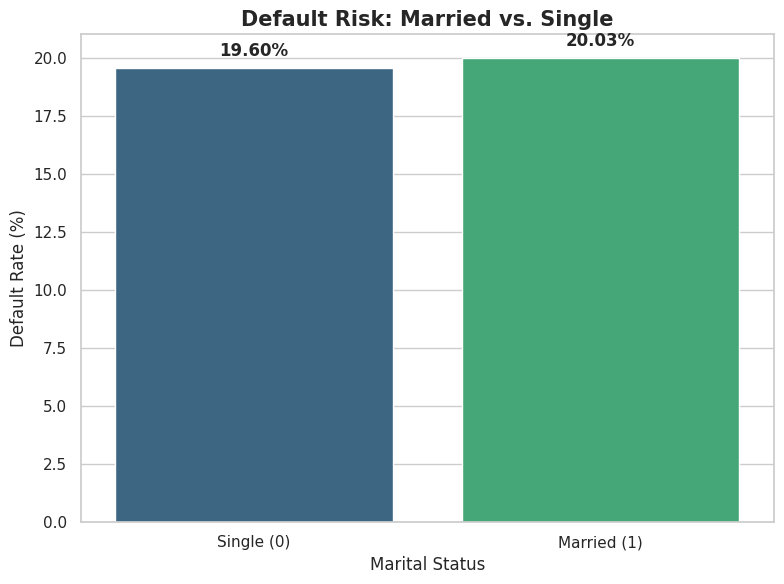

In [552]:
#VISUALIZATION FOR THE RESEARCH QUESTION FOR MARITAL STATUS vs DEFAULT RATE

#Calculate the Risk by Marital Status
marital_risk = y_train.groupby(X_train['Married/Single']).mean() * 100

#Create the Plot
plt.figure(figsize=(8, 6))
#Mapping 0/1 to labels for the chart
labels = ['Single (0)', 'Married (1)']
sns.barplot(x=labels, y=marital_risk.values, hue=labels, palette='viridis', legend=False)

#Formatting
plt.title('Default Risk: Married vs. Single', fontsize=15, fontweight='bold')
plt.ylabel('Default Rate (%)', fontsize=12)
plt.xlabel('Marital Status', fontsize=12)

#Add percentage labels on top of bars
for i, val in enumerate(marital_risk.values):
    plt.text(i, val + 0.5, f'{val:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


**Interpretation of Marital Status vs Default Rate**

Single applicants demonstrate a lower likelihood of default (19.60%) than Married applicants (20.03%). This suggests that the financial flexibility of a single-person household is a more powerful predictor of loan repayment than the traditional stability associated with marriage

---

####**Age Group vs Default Rate**

**Question**: Does being older in terms of age make one less likely to default on loans?

In [553]:
'''
Age Binning: This step of feature engineering—converting continuous Age into categorical
Age_Category is essential for effective EDA because it allows us to test group-based hypotheses
that raw numbers cannot easily reveal.
'''

def age_binning(age_df):
    # Create the bins based on your hypothesis groups
    # 20-40 (Early), 40-60 (Mid), 60-80 (Senior)
    age_df['Age_Group'] = pd.cut(age_df['Age'],
                             bins=[20, 40, 60, 80],
                             labels=['Young_Adult', 'Middle_Aged', 'Senior'])

    #Convert these to dummy columns so the model can read them
    age_df = pd.get_dummies(age_df, columns=['Age_Group'], prefix='age', dtype=int)

    return age_df

#Apply to your actual training and testing data
X_train = age_binning(X_train)
X_test = age_binning(X_test)

#This removes any column that has a name we've already seen
X_train = X_train.loc[:, ~X_train.columns.duplicated()]
X_test = X_test.loc[:, ~X_test.columns.duplicated()]

#Check the list again
print(X_train.columns.tolist())
print(X_test.columns.tolist())

['Income', 'Age', 'Married/Single', 'Profession', 'CITY', 'STATE', 'CURRENT_JOB_YRS', 'Previous_Experience', 'profile_NoRentNoHouse_No_Car', 'profile_NoRentNoHouse_With_Car', 'profile_Owner_No_Car', 'profile_Owner_With_Car', 'profile_Renter_No_Car', 'profile_Renter_With_Car', 'house_tenure_10-11 Yrs', 'house_tenure_12-13 Yrs', 'house_tenure_14 Yrs (Max)', 'age_Young_Adult', 'age_Middle_Aged', 'age_Senior']
['Income', 'Age', 'Married/Single', 'Profession', 'CITY', 'STATE', 'CURRENT_JOB_YRS', 'Previous_Experience', 'profile_NoRentNoHouse_No_Car', 'profile_NoRentNoHouse_With_Car', 'profile_Owner_No_Car', 'profile_Owner_With_Car', 'profile_Renter_No_Car', 'profile_Renter_With_Car', 'house_tenure_10-11 Yrs', 'house_tenure_12-13 Yrs', 'house_tenure_14 Yrs (Max)', 'age_Young_Adult', 'age_Middle_Aged', 'age_Senior']


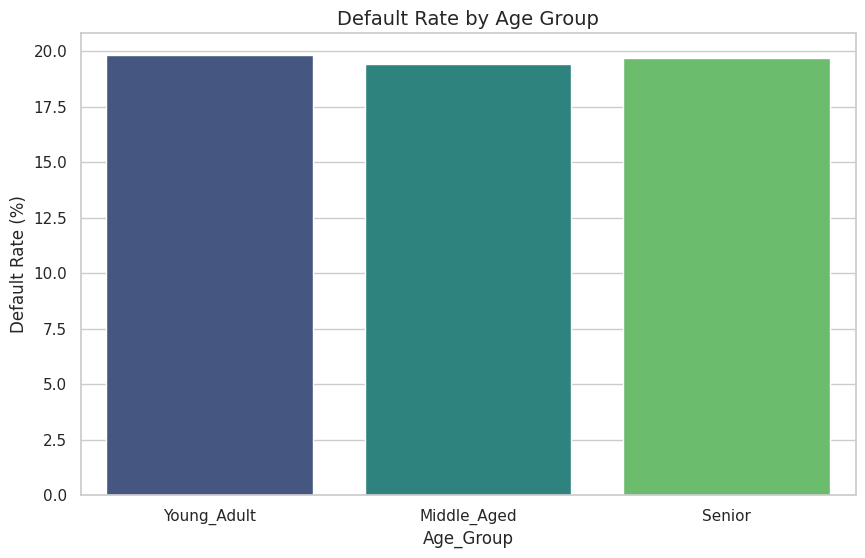

     Age_Group  Default_Rate
0  Young_Adult     19.821429
1  Middle_Aged     19.430229
2       Senior     19.678352


In [554]:
#VISUALIZATION FOR THE RESEARCH QUESTION FOR AGE_GROUP vs DEFAULT RATE

#Re-create the groups temporarily just for the calculation
temp_age_groups = pd.cut(X_train['Age'],
                         bins=[20, 40, 60, 80],
                         labels=['Young_Adult', 'Middle_Aged', 'Senior'])

#Combine with the target variable to calculate risk
# We use y_train (the Risk_Flag) and our temporary groups
age_risk_stats = y_train.groupby(temp_age_groups, observed=False).mean().reset_index()
age_risk_stats.columns = ['Age_Group', 'Default_Rate']

#Convert to percentage
age_risk_stats['Default_Rate'] = age_risk_stats['Default_Rate'] * 100

#Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(data=age_risk_stats, x='Age_Group', y='Default_Rate', hue='Age_Group', palette='viridis', legend=False)
plt.title('Default Rate by Age Group', fontsize=14)
plt.ylabel('Default Rate (%)')
plt.show()

print(age_risk_stats)

**Interpretation for Age_Group vs Defaulter Rate**

The middle aged customers have the lowest default rate 19.43, they are considered the safe borrowers compared to the other age groups.Seniors (19.68%) were only slightly less likely to default than Young Adults (19.82%). While this supports the idea that older age were less like to default on their loans due to being more financially stable, the 0.14% gap is too small for age to be a primary factor for customers to default on their loans. Additional advanced feature interactions with other features could help to find the real risk patterns.



In [555]:
#The Raw column "Age" has to be dropped because the Age Bins are better for the model to be used.
cols_to_drop = ["Age"]

#Drop from both sets
X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

# Verify the clean list for both the Train and Test Dataframe(This is important because they have to mirror each other)
print("Cleaned X_train Columns:", X_train.columns.tolist())
print("Cleaned X_test Columns:", X_train.columns.tolist())

Cleaned X_train Columns: ['Income', 'Married/Single', 'Profession', 'CITY', 'STATE', 'CURRENT_JOB_YRS', 'Previous_Experience', 'profile_NoRentNoHouse_No_Car', 'profile_NoRentNoHouse_With_Car', 'profile_Owner_No_Car', 'profile_Owner_With_Car', 'profile_Renter_No_Car', 'profile_Renter_With_Car', 'house_tenure_10-11 Yrs', 'house_tenure_12-13 Yrs', 'house_tenure_14 Yrs (Max)', 'age_Young_Adult', 'age_Middle_Aged', 'age_Senior']
Cleaned X_test Columns: ['Income', 'Married/Single', 'Profession', 'CITY', 'STATE', 'CURRENT_JOB_YRS', 'Previous_Experience', 'profile_NoRentNoHouse_No_Car', 'profile_NoRentNoHouse_With_Car', 'profile_Owner_No_Car', 'profile_Owner_With_Car', 'profile_Renter_No_Car', 'profile_Renter_With_Car', 'house_tenure_10-11 Yrs', 'house_tenure_12-13 Yrs', 'house_tenure_14 Yrs (Max)', 'age_Young_Adult', 'age_Middle_Aged', 'age_Senior']


---

####**Previous_Experience Vs Default Rate**

**Question**: Does a customer with more previous work experience make them less likely to default on their loans?

In [556]:
'''
Previous_Experience Binning: This step of feature engineering—converting continuous Previous Experience into categorical
Previous_Exp_Group is essential for effective EDA because it allows us to test group-based hypotheses
that raw numbers cannot easily reveal.

Previous Experience Binning: we can determine if career stability is a more powerful predictor of risk.
'''

def pre_experience_binning(exp_df):
    # 1. Create the bins based on previous work experience groups
    # -1 to 4, 5 to 8, 9-12, 13-17
    exp_df['Previous_Experience_Group'] = pd.cut(exp_df['Previous_Experience'],
                                     bins=[-1, 4, 8, 12, 18],
                                     labels=['0-4', '5-8', '9-12', '13-17'])

    #Convert these to dummy columns (1s and 0s)
    exp_df = pd.get_dummies(exp_df, columns=['Previous_Experience_Group'], prefix='pre_exp', dtype=int)

    return exp_df

#Apply to your actual training and testing data
X_train = pre_experience_binning(X_train)
X_test = pre_experience_binning(X_test)

#Check the list to see your new 'exp_' columns
print("X_train columns:", X_train.columns.tolist())
print("X_test columns:", X_test.columns.tolist())

X_train columns: ['Income', 'Married/Single', 'Profession', 'CITY', 'STATE', 'CURRENT_JOB_YRS', 'Previous_Experience', 'profile_NoRentNoHouse_No_Car', 'profile_NoRentNoHouse_With_Car', 'profile_Owner_No_Car', 'profile_Owner_With_Car', 'profile_Renter_No_Car', 'profile_Renter_With_Car', 'house_tenure_10-11 Yrs', 'house_tenure_12-13 Yrs', 'house_tenure_14 Yrs (Max)', 'age_Young_Adult', 'age_Middle_Aged', 'age_Senior', 'pre_exp_0-4', 'pre_exp_5-8', 'pre_exp_9-12', 'pre_exp_13-17']
X_test columns: ['Income', 'Married/Single', 'Profession', 'CITY', 'STATE', 'CURRENT_JOB_YRS', 'Previous_Experience', 'profile_NoRentNoHouse_No_Car', 'profile_NoRentNoHouse_With_Car', 'profile_Owner_No_Car', 'profile_Owner_With_Car', 'profile_Renter_No_Car', 'profile_Renter_With_Car', 'house_tenure_10-11 Yrs', 'house_tenure_12-13 Yrs', 'house_tenure_14 Yrs (Max)', 'age_Young_Adult', 'age_Middle_Aged', 'age_Senior', 'pre_exp_0-4', 'pre_exp_5-8', 'pre_exp_9-12', 'pre_exp_13-17']


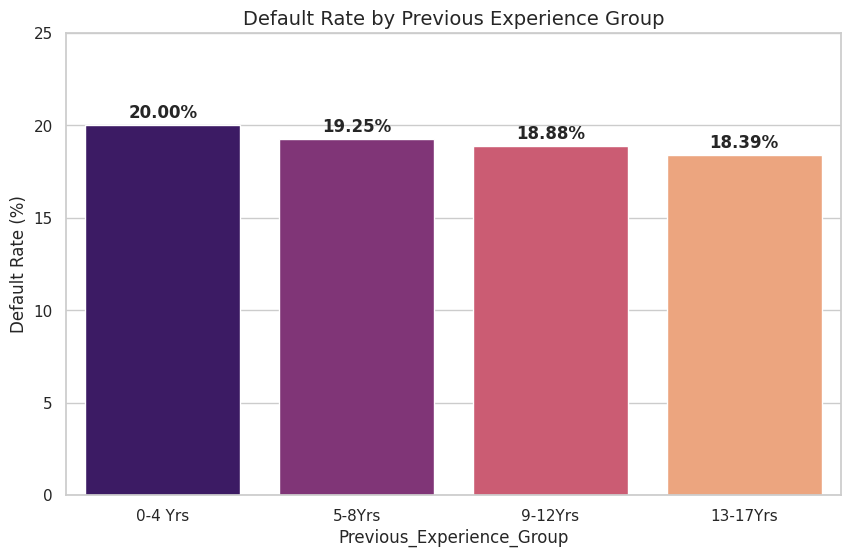

  Previous_Experience_Group  Default_Rate
0                   0-4 Yrs     20.003586
1                    5-8Yrs     19.246127
2                   9-12Yrs     18.881830
3                  13-17Yrs     18.390244


In [557]:
#VISUALIZATION FOR THE RESEARCH QUESTION FOR PREVIOUS EXPERIENCE vs DEFAULT RATE

#Re-create the groups temporarily just for the calculation
#We use the same bins as your binning function: -1 to 4 , 5 to 8, 9 to 12, 13 to 17
temp_pre_exp_groups = pd.cut(X_train['Previous_Experience'],
                         bins=[-1, 4, 8, 12, 17],
                         labels=['0-4 Yrs', '5-8Yrs', '9-12Yrs', '13-17Yrs'])
#Combine with the target variable (y_train) to calculate risk
exp_risk_stats = y_train.groupby(temp_pre_exp_groups, observed=False).mean().reset_index()
exp_risk_stats.columns = ['Previous_Experience_Group', 'Default_Rate']

#Convert the decimal into a percentage
exp_risk_stats['Default_Rate'] = exp_risk_stats['Default_Rate'] * 100

#Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(data=exp_risk_stats, x='Previous_Experience_Group', y='Default_Rate',
            hue='Previous_Experience_Group', palette='magma', legend=False)

#Add data labels on top of the bars for clarity
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')

plt.title('Default Rate by Previous Experience Group', fontsize=14)
plt.ylabel('Default Rate (%)')
plt.ylim(0, max(exp_risk_stats['Default_Rate']) + 5) # Adds space for the labels
plt.show()

print(exp_risk_stats)

**Interpretation for the Previous_Experience vs Default Rate**

Analysis demonstrates a direct correlation between professional previous work experience and loan reliability. We observed a consistent decline in default risk as previous work experience increases, dropping from 20.00% for 0-4 years individuals to a low of 18.39% for 13-14 years of previous work experience. This proves that professional previous work experience longevity is one of the most stable indicators of a borrower's ability to have handled financial responsibilities a long time.


In [558]:
#The Raw column "Previous_Experience" and the duplicated bins have to be dropped because the Previous Experience bins that are there are better for the model to be used to train.
cols_to_drop = ["Previous_Experience"]

#Drop from both sets
X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

# Verify the clean list for both the Train and Test Dataframe(This is important because they have to mirror each other)
print("Cleaned X_train Columns:", X_train.columns.tolist())
print("Cleaned X_test Columns:", X_train.columns.tolist())

Cleaned X_train Columns: ['Income', 'Married/Single', 'Profession', 'CITY', 'STATE', 'CURRENT_JOB_YRS', 'profile_NoRentNoHouse_No_Car', 'profile_NoRentNoHouse_With_Car', 'profile_Owner_No_Car', 'profile_Owner_With_Car', 'profile_Renter_No_Car', 'profile_Renter_With_Car', 'house_tenure_10-11 Yrs', 'house_tenure_12-13 Yrs', 'house_tenure_14 Yrs (Max)', 'age_Young_Adult', 'age_Middle_Aged', 'age_Senior', 'pre_exp_0-4', 'pre_exp_5-8', 'pre_exp_9-12', 'pre_exp_13-17']
Cleaned X_test Columns: ['Income', 'Married/Single', 'Profession', 'CITY', 'STATE', 'CURRENT_JOB_YRS', 'profile_NoRentNoHouse_No_Car', 'profile_NoRentNoHouse_With_Car', 'profile_Owner_No_Car', 'profile_Owner_With_Car', 'profile_Renter_No_Car', 'profile_Renter_With_Car', 'house_tenure_10-11 Yrs', 'house_tenure_12-13 Yrs', 'house_tenure_14 Yrs (Max)', 'age_Young_Adult', 'age_Middle_Aged', 'age_Senior', 'pre_exp_0-4', 'pre_exp_5-8', 'pre_exp_9-12', 'pre_exp_13-17']


---

####**CURRENT_JOB_YRS Vs Default Rate**

**Question**: Does staying at one job for a long time actually make a person less likely to default on a loan?

In [559]:
'''
CURRENT_JOB_YRS Binning: This step of feature engineering—converting continuous CURRENT_JOB_YRS into categorical
Job Tenure Group is essential for effective EDA because it allows us to test group-based hypotheses
that raw numbers cannot easily reveal.

CURRENT_JOB_YRS Binning: we can determine if job tenure is a powerful predictor of risk.
'''

def job_tenure_binning(jb_tenure_df):
    # 1. Create the bins based on career stages
    # -1 to 2 (New), 3 to 7 (Established), 8 T0 14 (Veteran)
    jb_tenure_df['Job_Tenure_Group'] = pd.cut(jb_tenure_df['CURRENT_JOB_YRS'],
                                     bins = [-1, 2, 7, 14],
                                     labels = ['0-2 Yrs (New)', '3-7 Yrs (Established)', '8-14 Yrs (Veteran)'])

    #Convert these to dummy columns (1s and 0s)
    jb_tenure_df = pd.get_dummies(jb_tenure_df, columns=['Job_Tenure_Group'], prefix='job_tenure', dtype=int)

    return jb_tenure_df

#Apply to your actual training and testing data
X_train = job_tenure_binning(X_train)
X_test = job_tenure_binning(X_test)

#This removes any column that has a name we've already seen
X_train = X_train.loc[:, ~X_train.columns.duplicated()]
X_test = X_test.loc[:, ~X_test.columns.duplicated()]

#Check the list to see your new 'exp_' columns
print("X_train columns:", X_train.columns.tolist())
print("X_test columns:", X_test.columns.tolist())

X_train columns: ['Income', 'Married/Single', 'Profession', 'CITY', 'STATE', 'CURRENT_JOB_YRS', 'profile_NoRentNoHouse_No_Car', 'profile_NoRentNoHouse_With_Car', 'profile_Owner_No_Car', 'profile_Owner_With_Car', 'profile_Renter_No_Car', 'profile_Renter_With_Car', 'house_tenure_10-11 Yrs', 'house_tenure_12-13 Yrs', 'house_tenure_14 Yrs (Max)', 'age_Young_Adult', 'age_Middle_Aged', 'age_Senior', 'pre_exp_0-4', 'pre_exp_5-8', 'pre_exp_9-12', 'pre_exp_13-17', 'job_tenure_0-2 Yrs (New)', 'job_tenure_3-7 Yrs (Established)', 'job_tenure_8-14 Yrs (Veteran)']
X_test columns: ['Income', 'Married/Single', 'Profession', 'CITY', 'STATE', 'CURRENT_JOB_YRS', 'profile_NoRentNoHouse_No_Car', 'profile_NoRentNoHouse_With_Car', 'profile_Owner_No_Car', 'profile_Owner_With_Car', 'profile_Renter_No_Car', 'profile_Renter_With_Car', 'house_tenure_10-11 Yrs', 'house_tenure_12-13 Yrs', 'house_tenure_14 Yrs (Max)', 'age_Young_Adult', 'age_Middle_Aged', 'age_Senior', 'pre_exp_0-4', 'pre_exp_5-8', 'pre_exp_9-12', '

<Figure size 1000x600 with 0 Axes>

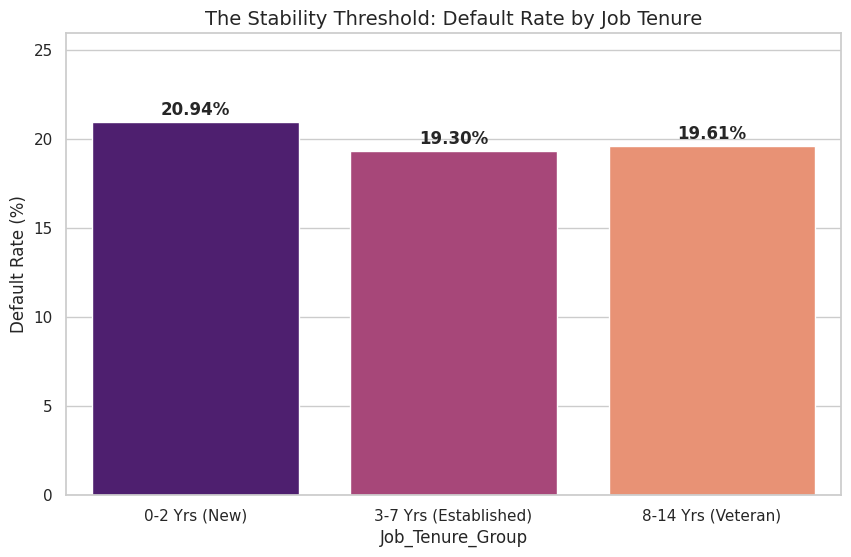

        Job_Tenure_Group  Default_Rate
0          0-2 Yrs (New)     20.935961
1  3-7 Yrs (Established)     19.300404
2     8-14 Yrs (Veteran)     19.606755


In [560]:
#VISUALIZATION FOR THE RESEARCH QUESTION FOR CURRENT_JOB_YRS vs DEFAULT RATE

#Re-create the groups temporarily just for the calculation
#We use the same bins as your binning function: -1 to 2 , 3 to 7, 8 to 14
temp_jb_tenure_groups = pd.cut(X_train['CURRENT_JOB_YRS'],
                                     bins = [-1, 2, 7, 14],
                                     labels = ['0-2 Yrs (New)', '3-7 Yrs (Established)', '8-14 Yrs (Veteran)'])
#Combine with the target variable (y_train) to calculate risk
jb_tenure_risk_stats = y_train.groupby(temp_jb_tenure_groups, observed=False).mean().reset_index()
jb_tenure_risk_stats.columns = ['Job_Tenure_Group', 'Default_Rate']

#Convert the decimal into a percentage
jb_tenure_risk_stats['Default_Rate'] = jb_tenure_risk_stats['Default_Rate'] * 100

#Visualization Code
plt.figure(figsize=(10, 6))

#Visualization
#Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(data=jb_tenure_risk_stats, x='Job_Tenure_Group', y='Default_Rate',
            hue='Job_Tenure_Group', palette='magma', legend=False)

#Add data labels on top of the bars for clarity
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')

plt.title('The Stability Threshold: Default Rate by Job Tenure', fontsize=14)
plt.ylabel('Default Rate (%)')
plt.ylim(0, max(jb_tenure_risk_stats['Default_Rate']) + 5) # Adds space for the labels
plt.show()

print(jb_tenure_risk_stats)

**Interpretation for the CURRENT_JOB_YEARS vs Default Risk**

The analysis reveals that job stability is a non-linear predictor of risk. The highest default rate (20.94%) occurs within the first two years of employment, representing early tenure volatility. Reliability peaks in the 3-7 year 'Established' window (19.30%), before rising slightly as employees reach 'Veteran' status. This suggests that the 'Sweet Spot' for lending is to those who have moved past the initial risks of a new role but remain in the peak of their professional stability, which is the established group.

In [561]:
#The Raw column "CURRENT_JOB_YRS" and the duplicated bins have to be dropped because the CURRENT_JOB_YRS bins that are there are better for the model to be used to train.
cols_to_drop = ["CURRENT_JOB_YRS",]

#Drop from both sets
X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

# Verify the clean list for both the Train and Test Dataframe(This is important because they have to mirror each other)
print("Cleaned X_train Columns:", X_train.columns.tolist())
print("Cleaned X_test Columns:", X_train.columns.tolist())

Cleaned X_train Columns: ['Income', 'Married/Single', 'Profession', 'CITY', 'STATE', 'profile_NoRentNoHouse_No_Car', 'profile_NoRentNoHouse_With_Car', 'profile_Owner_No_Car', 'profile_Owner_With_Car', 'profile_Renter_No_Car', 'profile_Renter_With_Car', 'house_tenure_10-11 Yrs', 'house_tenure_12-13 Yrs', 'house_tenure_14 Yrs (Max)', 'age_Young_Adult', 'age_Middle_Aged', 'age_Senior', 'pre_exp_0-4', 'pre_exp_5-8', 'pre_exp_9-12', 'pre_exp_13-17', 'job_tenure_0-2 Yrs (New)', 'job_tenure_3-7 Yrs (Established)', 'job_tenure_8-14 Yrs (Veteran)']
Cleaned X_test Columns: ['Income', 'Married/Single', 'Profession', 'CITY', 'STATE', 'profile_NoRentNoHouse_No_Car', 'profile_NoRentNoHouse_With_Car', 'profile_Owner_No_Car', 'profile_Owner_With_Car', 'profile_Renter_No_Car', 'profile_Renter_With_Car', 'house_tenure_10-11 Yrs', 'house_tenure_12-13 Yrs', 'house_tenure_14 Yrs (Max)', 'age_Young_Adult', 'age_Middle_Aged', 'age_Senior', 'pre_exp_0-4', 'pre_exp_5-8', 'pre_exp_9-12', 'pre_exp_13-17', 'job_t

---

#### **Income Vs Default Risk**
**Question**: Does having a high annual income guarantee being a lower risk defaulter?

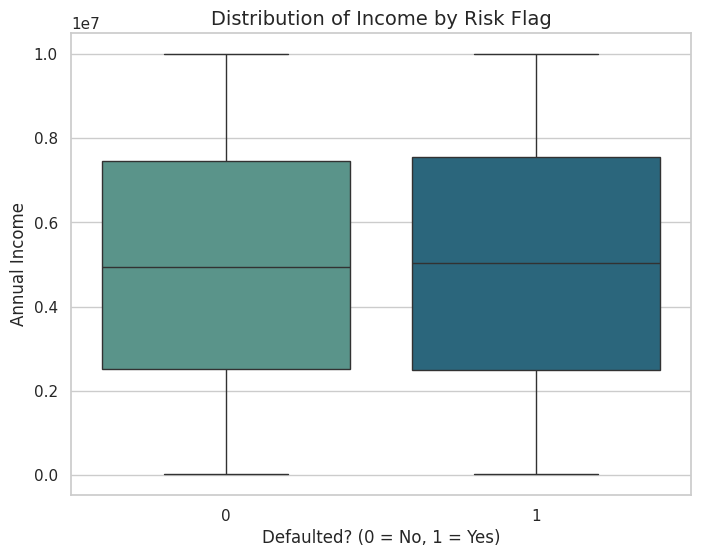

In [562]:
#VISUALIZATION FOR THE INCOME vs DEFAULT RATE RESEARCH QUESTION

plt.figure(figsize=(8, 6))
sns.boxplot(x=y_train, y=X_train['Income'], hue=y_train, palette='crest', legend=False)

plt.title('Distribution of Income by Risk Flag', fontsize=14)
plt.xlabel('Defaulted? (0 = No, 1 = Yes)')
plt.ylabel('Annual Income')
plt.show()

**Interpretation for Income vs Default Rate**

Annual income is traditionally viewed as a primary indicator of credit risk, our box plot analysis reveals a more complex reality. The almost perfect overlap in income distributions between low-risk and high-risk groups suggests that, for this population, income is a neutral factor. This outcome highlights that a high salary does not inherently guarantee loan repayment.

---

####**City and State Vs Defaulter Risk**
**Question**: Is a customer's specific city (local data) a stronger warning sign for loan default than the state (region data) they live in?

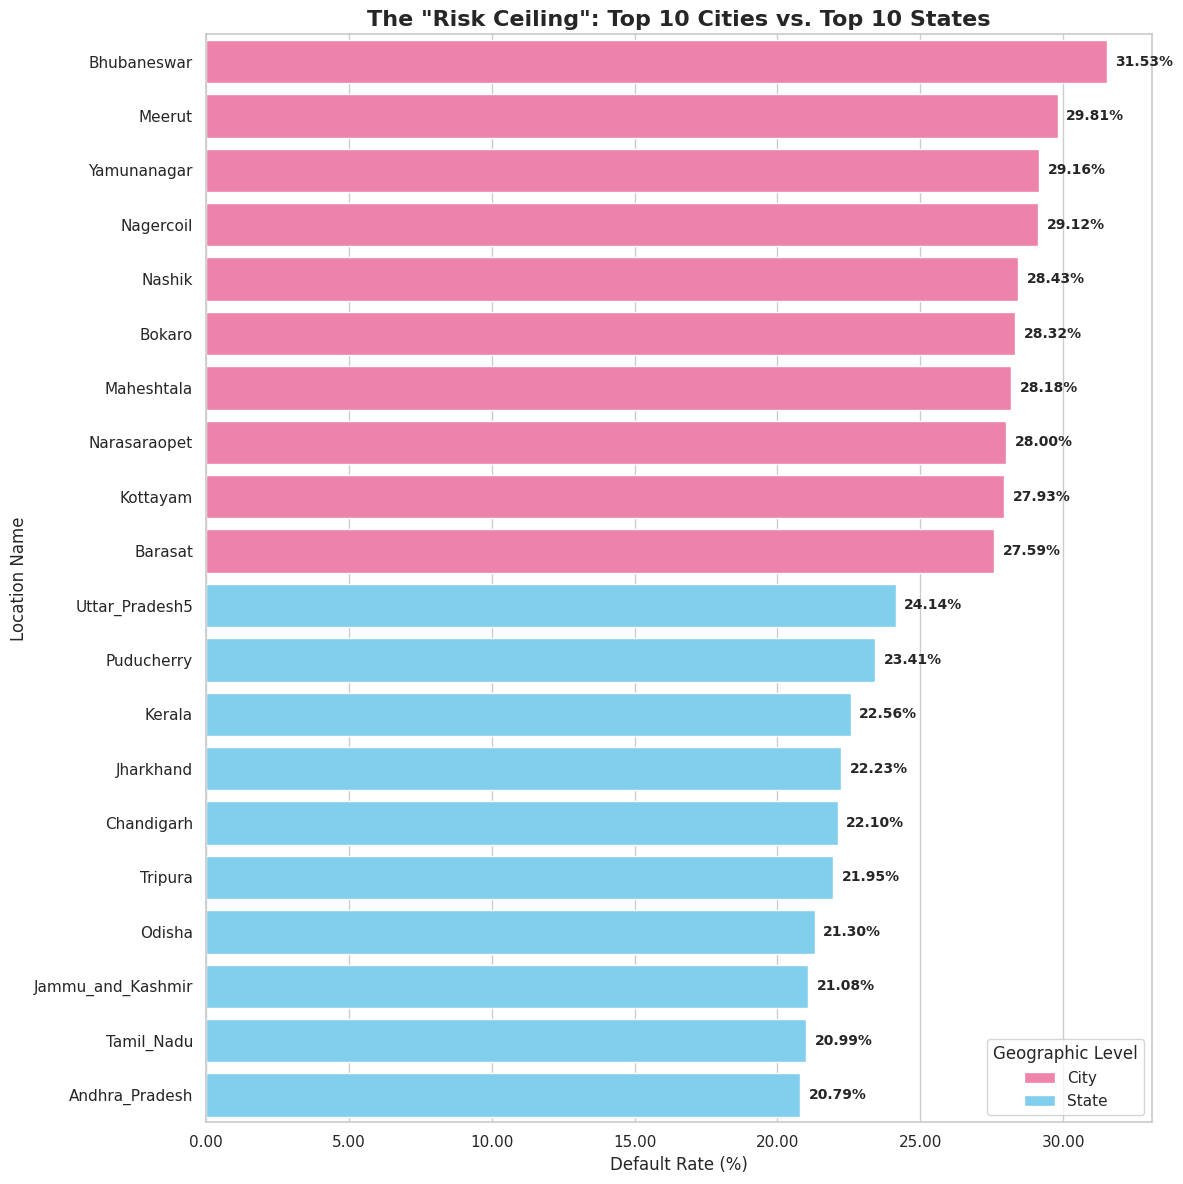

In [563]:
#VISUALIZATION FOR RESEARCH QUESTION FOR CITY AND STATE Vs DEFAULT RATE


#Get the Top 10 High-Risk Scores from X_train
top_state_scores = sorted(X_train['STATE'].unique(), reverse=True)[:10]
top_city_scores = sorted(X_train['CITY'].unique(), reverse=True)[:10]

#Build a combined dataset for the Overlapping effect
comparison_data = []

#Map State Names
for score in top_state_scores:
    idx = X_train[X_train['STATE'] == score].index[0]
    name = str(orig_df.loc[idx, 'STATE']).replace('[', '').replace(']', '').strip()
    comparison_data.append({'Location': name, 'Default_Rate_%': score * 100, 'Level': 'State'})

#Map City Names
for score in top_city_scores:
    idx = X_train[X_train['CITY'] == score].index[0]
    name = str(orig_df.loc[idx, 'CITY']).replace('[', '').replace(']', '').strip()
    comparison_data.append({'Location': name, 'Default_Rate_%': score * 100, 'Level': 'City'})

viz_df = pd.DataFrame(comparison_data).sort_values('Default_Rate_%', ascending=False)

#Create the Visualization
plt.figure(figsize=(12, 12))

#We use 'hue' to separate States and Cities visually in the same list
sns.barplot(data=viz_df, x='Default_Rate_%', y='Location', hue='Level', palette={'State': '#70d6ff', 'City': '#ff70a6'})

#Formatting
plt.title('The "Risk Ceiling": Top 10 Cities vs. Top 10 States', fontsize=16, fontweight='bold')
plt.xlabel('Default Rate (%)', fontsize=12)
plt.ylabel('Location Name', fontsize=12)
plt.gca().xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
plt.legend(title='Geographic Level', loc='lower right')

#Add the percentage labels to the ends of the bars
for p in plt.gca().patches:
    width = p.get_width()
    if width > 0: # Ensure we only label actual bars
        plt.gca().annotate(f'{width:.2f}%', (width + 0.3, p.get_y() + p.get_height() / 2),
                        va='center', fontweight='bold', fontsize=10)



plt.tight_layout()
plt.show()

**Interpretation for City and State vs Default Rate**

The chart above identifies which 10 states and cities have the highest percentage of people who did not pay back their loans. Only 10 cities and states were used because there are hundreds of cities so its best to look at the worst 10. The barplot above used Granularity. This is when we move from a large view in this case the state to a small view the city. The pink bars(city) are all higher than the blue bars(state) which proves that the local data (city) is a  stronger warning sign for loan default than the regional data(state). Target encoding of the city and state features helped us view closely on the geographical feature, city, to see those hidden risks that the feature state would have missed.

---

####**Profession Vs Default Risk**
**Question**: Does the profession one does have an affect on default rate?

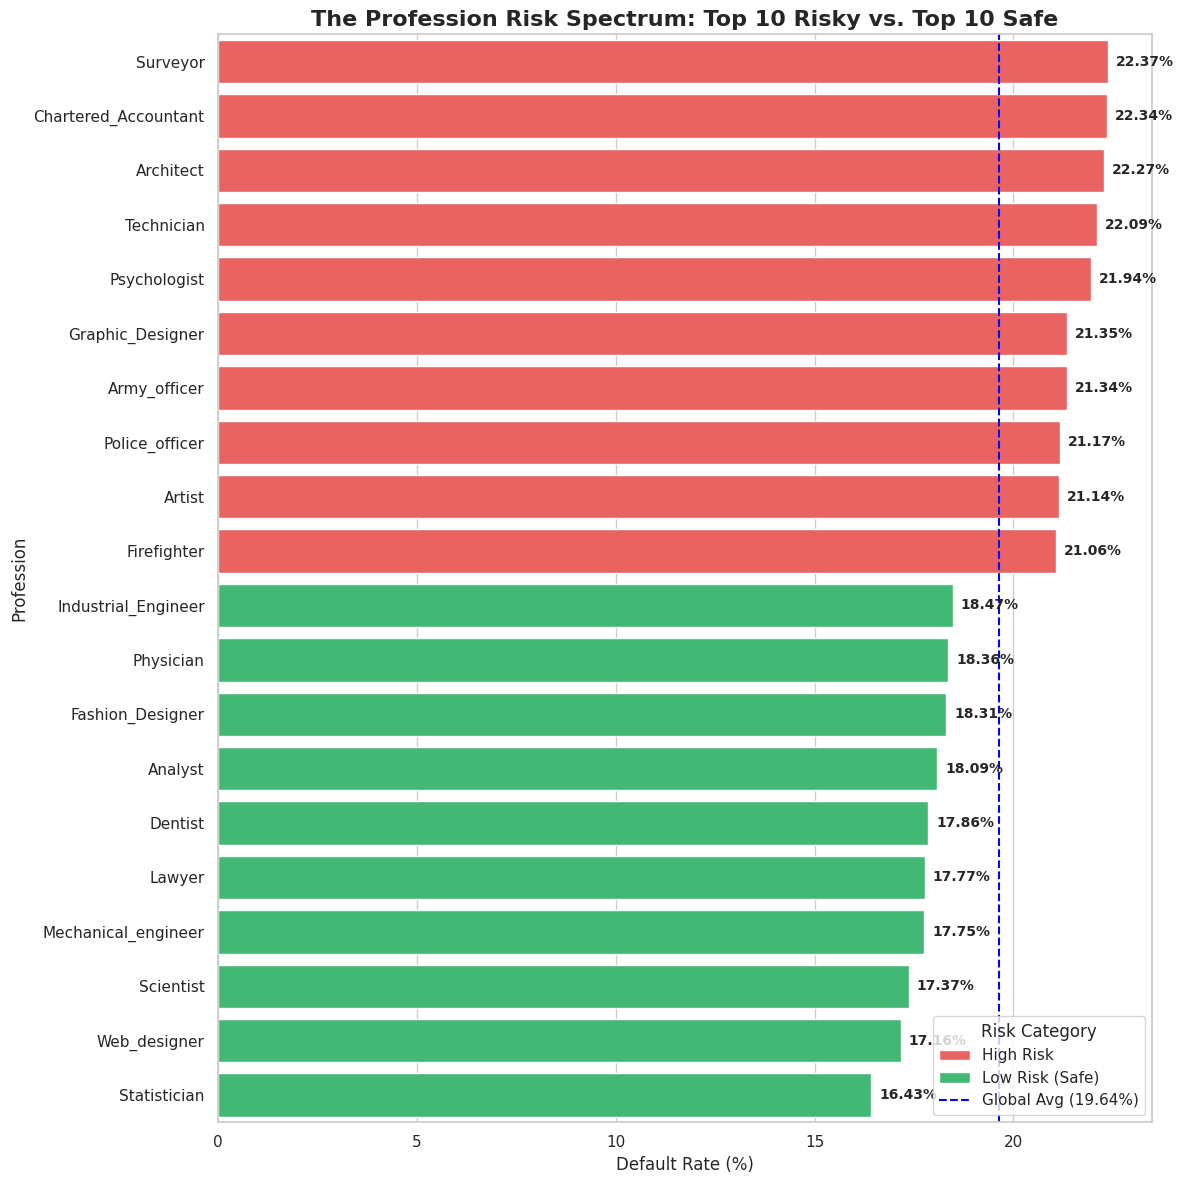

In [564]:
#VISUALIZATION FOR RESEARCH QUESTION FOR PROFESSION Vs DEFAULT RATE

#Calculate the Global Average Baseline
global_avg = y_train.mean() * 100

# Get All Unique Profession Scores and Names
# We pull the unique scores and match them to names from orig_df
prof_scores = X_train['Profession'].unique()
all_profs = []

for score in prof_scores:
    idx = X_train[X_train['Profession'] == score].index[0]
    raw_name = str(orig_df.loc[idx, 'Profession'])
    clean_name = raw_name.replace('[', '').replace(']', '').strip()
    all_profs.append({'Profession': clean_name, 'Default_Rate_%': score * 100})

#Sort to find the Extremes
full_prof_df = pd.DataFrame(all_profs).sort_values('Default_Rate_%', ascending=False)
top_10_risky = full_prof_df.head(10).copy()
top_10_safe = full_prof_df.tail(10).copy()

#Add labels for the chart
top_10_risky['Category'] = 'High Risk'
top_10_safe['Category'] = 'Low Risk (Safe)'

#Combine them for one visual
comparison_df = pd.concat([top_10_risky, top_10_safe])

#Visualization
plt.figure(figsize=(12, 12))
colors = {'High Risk': '#ff4d4d', 'Low Risk (Safe)': '#2ecc71'} # Red vs. Green

sns.barplot(data=comparison_df, x='Default_Rate_%', y='Profession',
            hue='Category', palette=colors, dodge=False)

#Add the Global Average "Safety Line"
plt.axvline(global_avg, color='blue', linestyle='--', label=f'Global Avg ({global_avg:.2f}%)')

#Formatting
plt.title('The Profession Risk Spectrum: Top 10 Risky vs. Top 10 Safe', fontsize=16, fontweight='bold')
plt.xlabel('Default Rate (%)', fontsize=12)
plt.legend(title='Risk Category', loc='lower right')
#Add values to the ends of the bars
for p in plt.gca().patches:
    width = p.get_width()
    if width > 0:
        plt.gca().annotate(f'{width:.2f}%', (width + 0.2, p.get_y() + p.get_height() / 2),
                        va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

**Interpretation of Profession vs Default Rate**
Analysis utilized the Global Average Risk (19.64%). The global average risk is the average percentage of anyone from the population in the dataset defaulting on their loan. Professions represented by Red Bars exhibit default rates significantly above this baseline, serving as primary indicators for high risk classification. Conversely, Green Bars identify professions with a lower than average risk profile, allowing the model to classify these applicants as low risk defaulters.

Professions appearing in the Red chart typically represent industries income volatility, so the professional status is not what makes one to be a high or low risk defaulter. However, the target encoded profession feature helped create an average risk rate of each profession in the dataframe that have a behaviour of being low or high risk defaulters.

---

#### **Features with High Influence on Credit Risk**

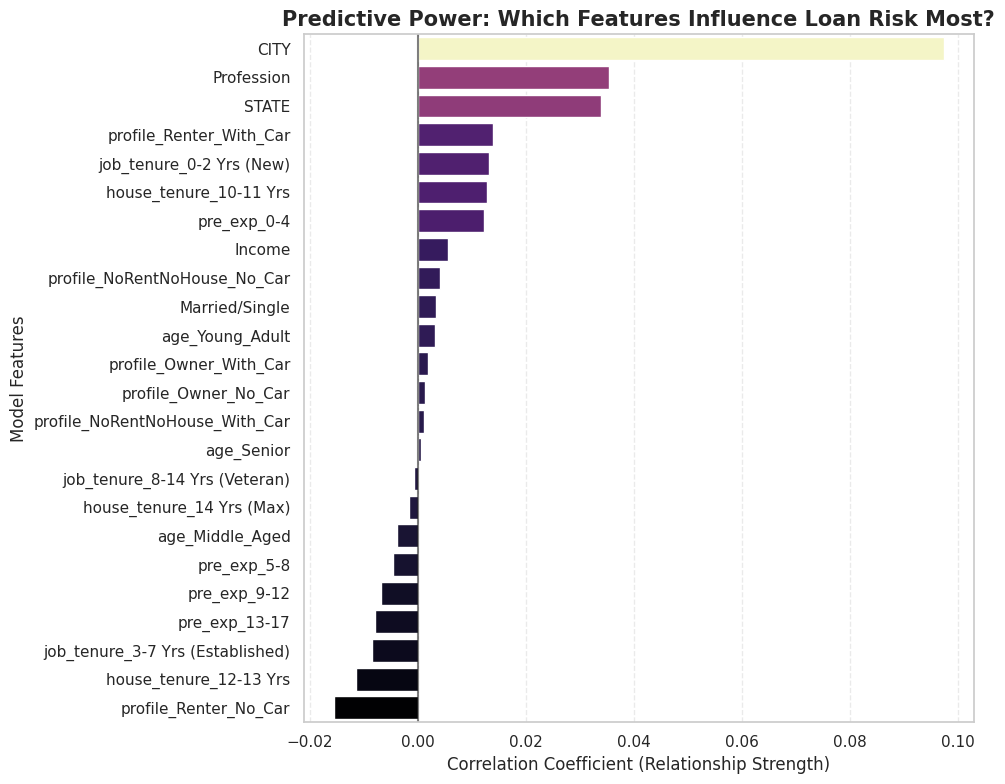

In [565]:
# We add the target to X_train temporarily just for this calculation
# This is faster than a full .copy() for large datasets
correlations = X_train.assign(Risk_Flag=y_train.values).corr()['Risk_Flag'].drop('Risk_Flag').sort_values(ascending=False)

# --- VISUALIZATION ---
plt.figure(figsize=(10, 8))

# Use the correlations results directly
sns.barplot(x=correlations.values, y=correlations.index, hue=correlations.values, palette='magma', legend=False)

# Customizing for a "Professional" look
plt.title('Predictive Power: Which Features Influence Loan Risk Most?', fontsize=15, fontweight='bold')
plt.xlabel('Correlation Coefficient (Relationship Strength)', fontsize=12)
plt.ylabel('Model Features', fontsize=12)

# Adds a center line at 0 to separate positive vs negative influencers
plt.axvline(x=0, color='black', linestyle='-', linewidth=1.5, alpha=0.5)
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

The bars to the right have a positive correlation to default risk. These features increase the risk so as these numbers goes up, the chance of default goes up as well. While the bars to the left have a negative correlation to default risk. These features decrease risk and are the safety signals for loan borrowing. The longer the bar is in either direction (to the right or to the left) the more powerful the feature has on the default rate. In our dataset, City is clear the most powerful feature that has a high default rate while the asset profile for renter with no car is the most powerful feature that has a low default rate for defaulters.

---

###Feature Scaling

Columns like Annual Income have large numbers like 50,000 and Age have small numbers like 25. If we don't scale, the machine learning model might think Income is more important just because the number is bigger. Scaling makes them comparable.

In [566]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the Scaler
scaler = StandardScaler()

# 2. Identify the columns to scale
# Usually, we scale all numerical columns.
# Since we've encoded everything, all 13 columns are now numbers!
cols_to_scale = X_train.columns

# 3. Fit on Train, Transform both
# IMPORTANT: We fit only on X_train to prevent the model from knowing
# anything about the average values in our "Test" set.
X_train_scaled = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled = scaler.transform(X_test[cols_to_scale])

# 4. Convert back to DataFrames (Scaling turns data into arrays)
X_train = pd.DataFrame(X_train_scaled, columns=cols_to_scale, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=cols_to_scale, index=X_test.index)

print("Scaling complete! Here is the new look of your data:")
print(X_train.head())

Scaling complete! Here is the new look of your data:
          Income  Married/Single  Profession      CITY     STATE  \
250934 -0.053897       -0.337062    1.743709  0.490320  1.233392   
230253  0.335697       -0.337062   -0.913138  0.412815 -0.744364   
235054  1.036910       -0.337062    0.727498  0.412815 -0.744364   
230563 -1.684271       -0.337062    0.727498 -0.424804 -0.251049   
224460  1.616740       -0.337062    1.209208  2.160977  0.848865   

        profile_NoRentNoHouse_No_Car  profile_NoRentNoHouse_With_Car  \
250934                     -0.145572                       -0.095612   
230253                     -0.145572                       -0.095612   
235054                     -0.145572                       -0.095612   
230563                     -0.145572                       -0.095612   
224460                     -0.145572                       -0.095612   

        profile_Owner_No_Car  profile_Owner_With_Car  profile_Renter_No_Car  \
250934             -0.1953

In [567]:
#FINALE DATAFRAME FOR TEST AND TRAIN DATA
print("X_train_final shape:", X_train.shape)
print("X_test_final shape:", X_test.shape)

print("X_train_final columns:", X_train.columns.tolist())
print("X_test_final columns:", X_test.columns.tolist())

X_train_final shape: (34552, 24)
X_test_final shape: (8638, 24)
X_train_final columns: ['Income', 'Married/Single', 'Profession', 'CITY', 'STATE', 'profile_NoRentNoHouse_No_Car', 'profile_NoRentNoHouse_With_Car', 'profile_Owner_No_Car', 'profile_Owner_With_Car', 'profile_Renter_No_Car', 'profile_Renter_With_Car', 'house_tenure_10-11 Yrs', 'house_tenure_12-13 Yrs', 'house_tenure_14 Yrs (Max)', 'age_Young_Adult', 'age_Middle_Aged', 'age_Senior', 'pre_exp_0-4', 'pre_exp_5-8', 'pre_exp_9-12', 'pre_exp_13-17', 'job_tenure_0-2 Yrs (New)', 'job_tenure_3-7 Yrs (Established)', 'job_tenure_8-14 Yrs (Veteran)']
X_test_final columns: ['Income', 'Married/Single', 'Profession', 'CITY', 'STATE', 'profile_NoRentNoHouse_No_Car', 'profile_NoRentNoHouse_With_Car', 'profile_Owner_No_Car', 'profile_Owner_With_Car', 'profile_Renter_No_Car', 'profile_Renter_With_Car', 'house_tenure_10-11 Yrs', 'house_tenure_12-13 Yrs', 'house_tenure_14 Yrs (Max)', 'age_Young_Adult', 'age_Middle_Aged', 'age_Senior', 'pre_exp_

##6. Evaluation of Machine Model



In [568]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Initialize the Model
#'max_iter' is increased to 1000 to ensure the math has enough time to "converge" (find the best fit)
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)

#Train the Model
#This is where the model learns the patterns between your features and the Risk_Flag
log_reg_model.fit(X_train, y_train)

#Make Predictions
#We predict on the Test set (the data the model hasn't seen yet)
y_pred = log_reg_model.predict(X_test)

#Evaluate the Results
print("--- Model Accuracy ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")

print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))

--- Model Accuracy ---
Accuracy Score: 0.8083

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.81      1.00      0.89      6982
           1       0.00      0.00      0.00      1656

    accuracy                           0.81      8638
   macro avg       0.40      0.50      0.45      8638
weighted avg       0.65      0.81      0.72      8638



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


* Accuracy(81%): The model predicted low risk (0) defaulter for every single row without looking at high risk (1) defaulter so the accuracy is meaningless. The model failed its job to find the customers that might default.
* Precision(0%): The model failed to label anyone as high risk.
* Recall(0%): The model caught 0% of the actual defaulter so every single risky person was approved for a loan.
* F1-Score(0%): Since precision and recall are zero, the F1-score(the balance between the two) is also zero.

* Initial automated model achieved 81% accuracy, but the detailed metrics showed a high 'False Negative' rate, it failed to catch any risky borrowers. This was as a result of Class Imbalance or Imbalance Data (class 1 = Risk_Flag(1) "High Risk" and class 0 = Risk_flag(0) "Low Risk" )

#### Using Weighted Logistic Regression Model To Balance the Dataset
**How it works**

By default, every customer is treated as "1 point." If you have 900 Low Risk and 100 High Risk customers, the model can get 90% accuracy just by ignoring the High Risk group entirely.

When you use class_weight="balanced", the model gives more "points" to the High Risk group. It essentially tells the algorithm: "Missing one High Risk customer is a much bigger mistake than mislabeling one Low Risk customer."

--- Logistic Regression (Balanced) Report ---
              precision    recall  f1-score   support

           0       0.81      0.56      0.66      6982
           1       0.19      0.44      0.27      1656

    accuracy                           0.54      8638
   macro avg       0.50      0.50      0.46      8638
weighted avg       0.69      0.54      0.58      8638



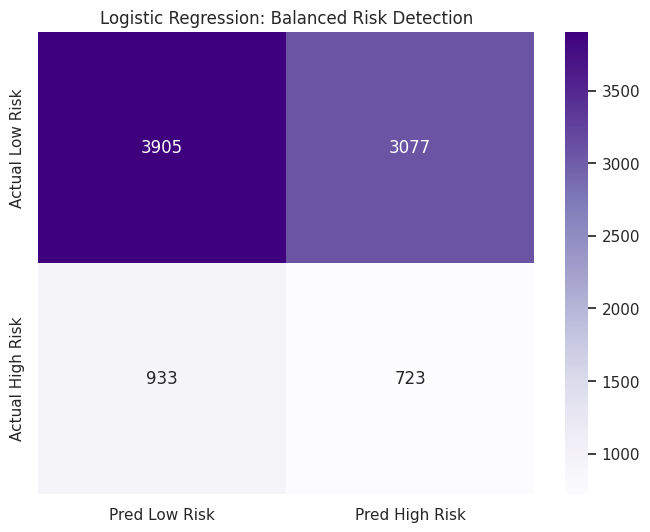

In [569]:
#Initialize with Class Weights(The classes are Risk_Flag(0) and Risk_Flag(1))
#'balanced' automatically calculates weights based on the frequency of your classes
#Or you can use a custom dictionary like {0: 1, 1: 4}
log_reg_model_weighted = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

#Train the model
log_reg_model_weighted.fit(X_train, y_train)

#Predict on the test data
log_predictions = log_reg_model_weighted.predict(X_test)

#Output the results
print("--- Logistic Regression (Balanced) Report ---")
print(classification_report(y_test, log_predictions))

#Visualize with Confusion Matrix
cm_log = confusion_matrix(y_test, log_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Pred Low Risk', 'Pred High Risk'],
            yticklabels=['Actual Low Risk', 'Actual High Risk'])
plt.title('Logistic Regression: Balanced Risk Detection')
plt.show()

* Accuracy(54%): The accuracy decreased from 81% to 54% but it is atleast struggling to distinguish between the two classes rather than just picking the most frequent class.
* Precision(19%): The model managed to label cusomers as high risk 19% of the time.
* Recall(44%): The model succesfully identified 43% of all actual defaulters in the dataset.
* F1-Score(27%): The average of precision and recall

* The balanced model is useful because caught nearly half of the bad loans (44% Recall) which is better than the initial standard model is useless because it caught none (0%) of the bad loans. This has made model sensitive, it will now over-flag leading to false positives.